In [3]:
import os, sys, glob, json, urllib.request, time
from pathlib import Path
import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# 下載 Google Noto Sans 繁體中文字體
font_url = "https://github.com/googlefonts/noto-cjk/raw/main/Sans/OTF/TraditionalChinese/NotoSansCJKtc-Regular.otf"
font_path = "NotoSansCJKtc-Regular.otf"
urllib.request.urlretrieve(font_url, font_path)

# 將字體加入 Matplotlib
fm.fontManager.addfont(font_path)

# 設定全域字體
plt.rc('font', family='Noto Sans CJK TC')

# 修復座標軸的負號 '-' 顯示問題
plt.rcParams['axes.unicode_minus'] = False

print("中文字體設定完成！現在畫圖可以顯示中文了。")

中文字體設定完成！現在畫圖可以顯示中文了。


In [4]:
import os
import gdown

DRIVE_FOLDER_URL = 'https://drive.google.com/drive/folders/1-BMCTI_hqfkLqppbm5k-DFfMiE-I5xnT'
DRIVE_FOLDER = '/root/smart_pole/data/高雄資料'
os.makedirs(DRIVE_FOLDER, exist_ok=True)

if not os.listdir(DRIVE_FOLDER):
    gdown.download_folder(
        DRIVE_FOLDER_URL,
        output=DRIVE_FOLDER,
        quiet=False,
        use_cookies=False,
        remaining_ok=True,   # 失敗的檔案跳過,不中斷
    )

assert os.path.exists(DRIVE_FOLDER), f'找不到 {DRIVE_FOLDER}'
files_in_drive = os.listdir(DRIVE_FOLDER)
print(f'資料夾共 {len(files_in_drive)} 個檔案')
print(f'前 5 個: {files_in_drive[:5]}')

資料夾共 1339 個檔案
前 5 個: ['10376006483.csv', '7485715088.csv', '9014577423.csv', '7510231087.csv', '9083719192.csv']


In [5]:
import os
DRIVE_FOLDER = '/root/smart_pole/data/高雄資料'
assert os.path.exists(DRIVE_FOLDER), f'找不到 {DRIVE_FOLDER}'
files_in_drive = os.listdir(DRIVE_FOLDER)
print(f'資料夾共 {len(files_in_drive)} 個檔案')
print(f'前 5 個: {files_in_drive[:5]}')

資料夾共 1339 個檔案
前 5 個: ['10376006483.csv', '7485715088.csv', '9014577423.csv', '7510231087.csv', '9083719192.csv']


In [6]:
import json
with open('/root/smart_pole/notebook.ipynb') as f:
    nb = json.load(f)
print(''.join(nb['cells'][-1]['source'])[:300])

# === 對齊 EPA 與竿體資料 + 視覺化 ===
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path

# --- 0. 確保中文字型可用 (這格獨立跑也 OK) ---
FONT_PATH = Path('/root/smart_pole/NotoSansCJKtc-Regular.otf')
if not FONT_PATH.exists():
    import u


EPA  : 2160 hr ×   12 站   2025-12-01 00:00:00 ~ 2026-02-28 23:00:00
Pole : 1456 hr × 1287 裝置  2025-12-04 00:00:00 ~ 2026-02-04 23:00:00

共同小時數 : 1456  (2025-12-04 00:00:00 ~ 2026-02-04 23:00:00)


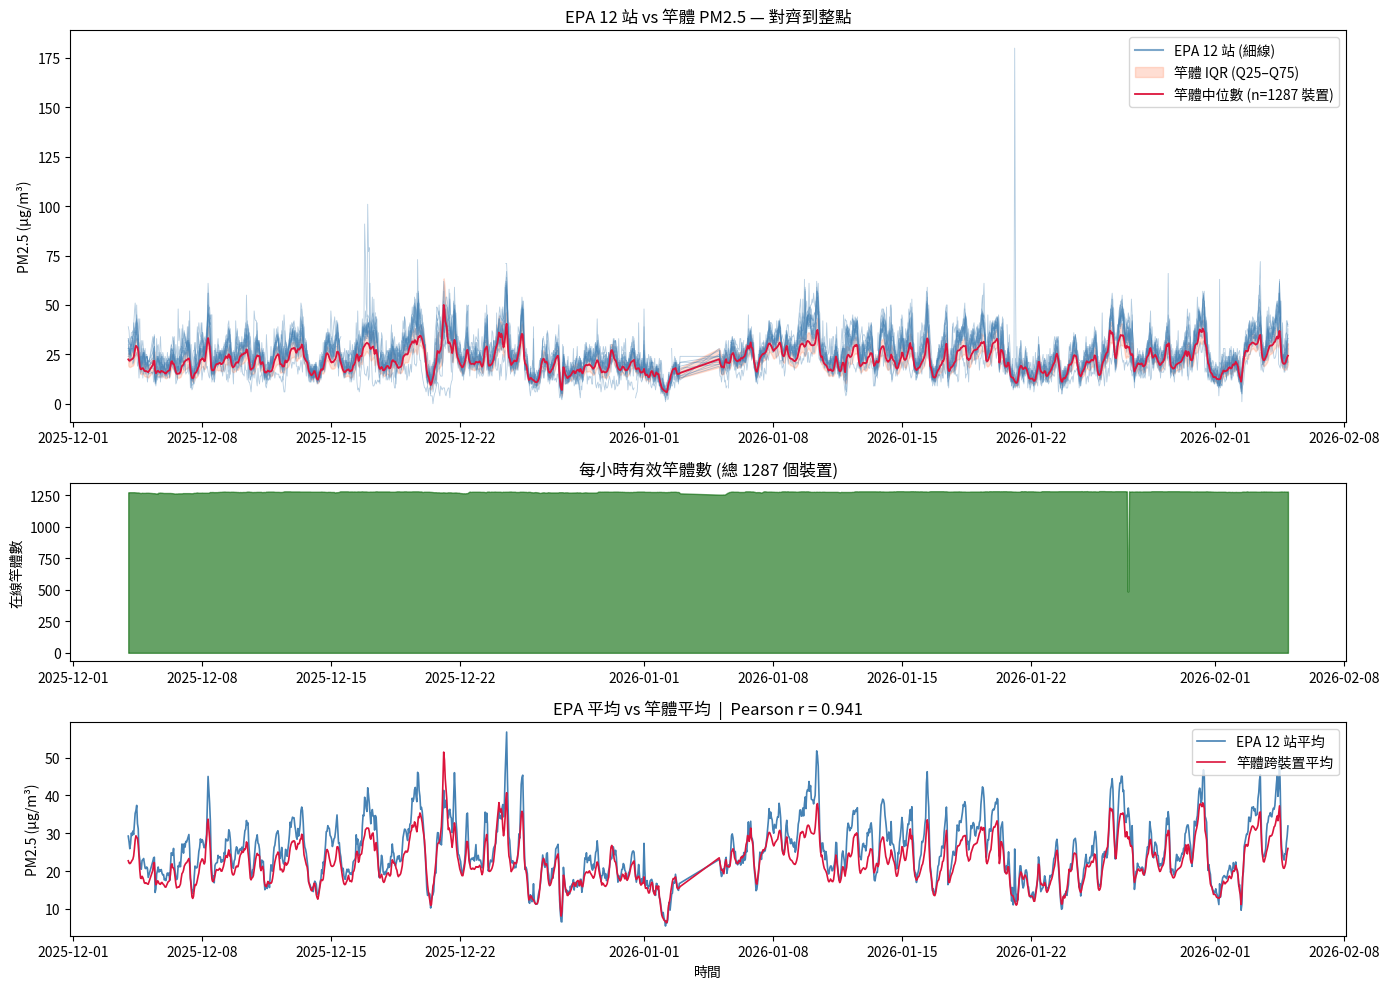


=== 對齊摘要 ===
  EPA  平均 PM2.5: 25.22   完整度: 99.2%
  竿體 平均 PM2.5: 22.37   完整度: 99.3%
  EPA / 竿體 平均比值: 0.887
  跨時 Pearson r    : 0.941


In [7]:
# === 對齊 EPA 與竿體資料 + 視覺化 ===
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from pathlib import Path

EPA_DIR    = Path('/root/smart_pole/data/epa_data')
POLE_DIR   = Path('/root/smart_pole/data/高雄資料')
POLE_CACHE = Path('/root/smart_pole/data/pole_hourly.parquet')

# --- 1. EPA → wide (hour × station) ---
epa_long = pd.concat([pd.read_csv(f, encoding='utf-8-sig')
                      for f in sorted(EPA_DIR.glob('epa_*.csv'))])
epa_long['time'] = pd.to_datetime(epa_long['time'])
epa_wide = (epa_long
            .pivot(index='time', columns='station', values='pm25')
            .sort_index())
print(f'EPA  : {epa_wide.shape[0]:4d} hr × {epa_wide.shape[1]:4d} 站   '
      f'{epa_wide.index.min()} ~ {epa_wide.index.max()}')

# --- 2. 竿體 → wide (hour × device),用 parquet cache ---
if not POLE_CACHE.exists():
    print(f'第一次建 cache: 掃描 {len(list(POLE_DIR.glob("*.csv")))} 個裝置 (~40 秒)…')
    df = (pl.scan_csv(str(POLE_DIR / '*.csv'), encoding='utf8-lossy',
                      schema_overrides={'deviceId': pl.Utf8, 'time': pl.Utf8,
                                        'PM2.5': pl.Float64})
          .with_columns(pl.col('time').str.to_datetime())
          .filter((pl.col('PM2.5') >= 0) & (pl.col('PM2.5') <= 1000))
          .sort('time')
          .group_by_dynamic('time', every='1h', group_by='deviceId')
          .agg(pl.col('PM2.5').mean())
          .collect())
    df.pivot(index='time', on='deviceId', values='PM2.5').sort('time').write_parquet(POLE_CACHE)

pole_wide = pd.read_parquet(POLE_CACHE).set_index('time').sort_index()
print(f'Pole : {pole_wide.shape[0]:4d} hr × {pole_wide.shape[1]:4d} 裝置  '
      f'{pole_wide.index.min()} ~ {pole_wide.index.max()}')

# --- 3. 對齊到共同時段 ---
common = epa_wide.index.intersection(pole_wide.index)
epa_w  = epa_wide.loc[common]
pole_w = pole_wide.loc[common]
print(f'\n共同小時數 : {len(common)}  ({common.min()} ~ {common.max()})')

# --- 4. 視覺化 ---
fig, axes = plt.subplots(3, 1, figsize=(14, 10),
                         gridspec_kw={'height_ratios': [2.2, 1, 1.2]})

# 4.1 全景時間序列: EPA 12 站 (淡藍細線) + 竿體中位數 + IQR
ax = axes[0]
for st in epa_w.columns:
    ax.plot(epa_w.index, epa_w[st], lw=0.6, alpha=0.4, color='steelblue')
ax.plot([], [], color='steelblue', alpha=0.7, label='EPA 12 站 (細線)')

pole_med = pole_w.median(axis=1)
pole_q25 = pole_w.quantile(0.25, axis=1)
pole_q75 = pole_w.quantile(0.75, axis=1)
ax.fill_between(pole_w.index, pole_q25, pole_q75,
                alpha=0.25, color='coral', label='竿體 IQR (Q25–Q75)')
ax.plot(pole_w.index, pole_med, lw=1.3, color='crimson',
        label=f'竿體中位數 (n={pole_w.shape[1]} 裝置)')
ax.set_ylabel('PM2.5 (μg/m³)')
ax.set_title('EPA 12 站 vs 竿體 PM2.5 — 對齊到整點')
ax.legend(loc='upper right')

# 4.2 每小時在線竿體數(資料覆蓋率診斷)
ax = axes[1]
active = pole_w.notna().sum(axis=1)
ax.fill_between(active.index, 0, active, color='darkgreen', alpha=0.6)
ax.set_ylabel('在線竿體數')
ax.set_title(f'每小時有效竿體數 (總 {pole_w.shape[1]} 個裝置)')

# 4.3 EPA 平均 vs 竿體平均 — 對齊驗證
ax = axes[2]
epa_mean  = epa_w.mean(axis=1)
pole_mean = pole_w.mean(axis=1)
ax.plot(epa_mean.index,  epa_mean,  lw=1.2, color='steelblue', label='EPA 12 站平均')
ax.plot(pole_mean.index, pole_mean, lw=1.2, color='crimson',   label='竿體跨裝置平均')
corr = epa_mean.corr(pole_mean)
ax.set_ylabel('PM2.5 (μg/m³)'); ax.set_xlabel('時間')
ax.set_title(f'EPA 平均 vs 竿體平均  |  Pearson r = {corr:.3f}')
ax.legend(loc='upper right')

plt.tight_layout(); plt.show()

# --- 5. 摘要 ---
print('\n=== 對齊摘要 ===')
print(f'  EPA  平均 PM2.5: {epa_mean.mean():5.2f}   完整度: {epa_w.notna().mean().mean()*100:.1f}%')
print(f'  竿體 平均 PM2.5: {pole_mean.mean():5.2f}   完整度: {pole_w.notna().mean().mean()*100:.1f}%')
print(f'  EPA / 竿體 平均比值: {pole_mean.mean()/epa_mean.mean():.3f}')
print(f'  跨時 Pearson r    : {corr:.3f}')
